In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import pickle
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import shap

In [11]:
X_balanced = pd.read_csv('../data/X_balanced.csv')
y_balanced = pd.read_csv('../data/y_balanced.csv').squeeze()

print("X_balanced shape:", X_balanced.shape)
print("Class distribution:\n", y_balanced.value_counts())

X_balanced shape: (59396, 11)
Class distribution:
 Churn
0    29698
1    29698
Name: count, dtype: int64


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_balanced
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (47516, 11)
Test size:  (11880, 11)


In [13]:
mlflow.set_experiment("gaming-churn-prediction")

models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42)
}

results = {}

for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name):
        # Train
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        
        # Metrics
        acc = accuracy_score(y_test, y_pred)
        auc_score = roc_auc_score(y_test, y_proba)
        
        # Log to MLflow
        mlflow.log_param("model", model_name)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("roc_auc", auc_score)
        mlflow.sklearn.log_model(model, model_name)
        
        results[model_name] = {
            "model": model,
            "accuracy": acc,
            "auc": auc_score,
            "y_pred": y_pred,
            "y_proba": y_proba
        }
        
        print(f"{model_name} → Accuracy: {acc:.4f} | AUC: {auc_score:.4f}")

print("\n✓ All models trained and logged to MLflow")

2026/03/04 15:43:53 INFO mlflow.tracking.fluent: Experiment with name 'gaming-churn-prediction' does not exist. Creating a new experiment.
2026/03/04 15:43:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/04 15:43:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest → Accuracy: 0.9672 | AUC: 0.9784


2026/03/04 15:44:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/04 15:44:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost → Accuracy: 0.9661 | AUC: 0.9782
[LightGBM] [Info] Number of positive: 23758, number of negative: 23758
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000791 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 47516, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


2026/03/04 15:44:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/04 15:44:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM → Accuracy: 0.9668 | AUC: 0.9781

✓ All models trained and logged to MLflow


In [14]:
best_model_name = max(results, key=lambda x: results[x]['auc'])
best_model = results[best_model_name]['model']
best_auc = results[best_model_name]['auc']
best_accuracy = results[best_model_name]['accuracy']

print(f"✓ Best Model: {best_model_name}")
print(f"  Accuracy: {best_accuracy:.4f}")
print(f"  AUC:      {best_auc:.4f}")

# Save best model
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save scaler placeholder (data already scaled in preprocessing)
# Just save column order for API use
col_order = list(X_balanced.columns)
with open('../models/col_order.pkl', 'wb') as f:
    pickle.dump(col_order, f)

print("✓ Saved best_model.pkl")
print("✓ Saved col_order.pkl")

✓ Best Model: RandomForest
  Accuracy: 0.9672
  AUC:      0.9784
✓ Saved best_model.pkl
✓ Saved col_order.pkl


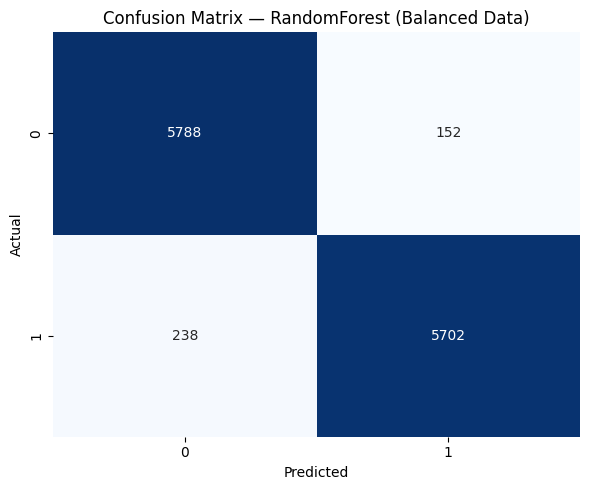

✓ Saved confusion_matrix_balanced.png


In [15]:
y_pred_best = results[best_model_name]['y_pred']

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix — {best_model_name} (Balanced Data)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix_balanced.png', dpi=150)
plt.show()
print("✓ Saved confusion_matrix_balanced.png")

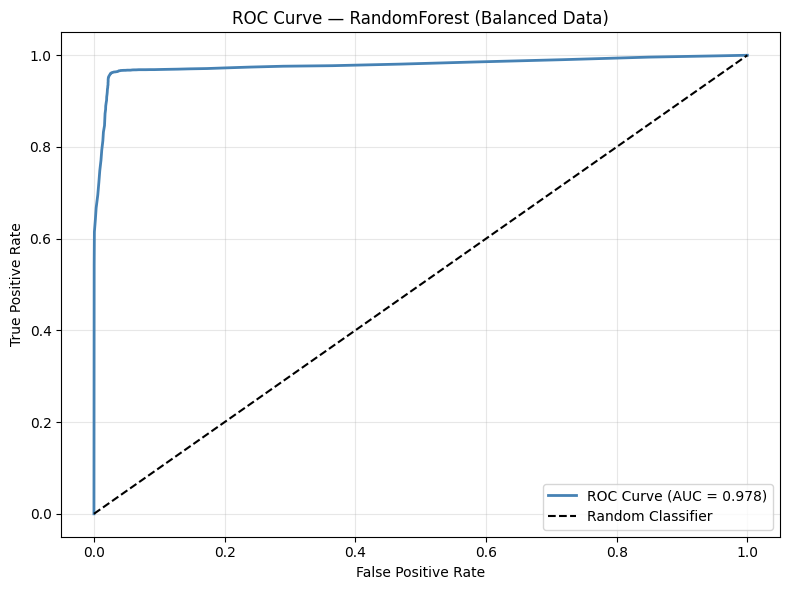

✓ Saved roc_curve_balanced.png


In [17]:
y_proba_best = results[best_model_name]['y_proba']
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
auc_val = roc_auc_score(y_test, y_proba_best)  # ← fixed, no auc() call

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_val:.3f})', linewidth=2, color='steelblue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve — {best_model_name} (Balanced Data)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/roc_curve_balanced.png', dpi=150)
plt.show()
print("✓ Saved roc_curve_balanced.png")

In [20]:
X_real = pd.read_csv('../data/X_processed.csv')
y_real = pd.read_csv('../data/y_processed.csv').squeeze()

# Flip labels to match balanced data (same fix we did in GAN notebook)
y_real_fixed = y_real.map({1: 0, 0: 1})

print("Real data shape:", X_real.shape)
print("Real class distribution AFTER fix:\n", y_real_fixed.value_counts())

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real, y_real_fixed,
    test_size=0.2,
    random_state=42,
    stratify=y_real_fixed
)

print(f"\nReal test set size: {X_test_real.shape}")

Real data shape: (40034, 11)
Real class distribution AFTER fix:
 Churn
0    29698
1    10336
Name: count, dtype: int64

Real test set size: (8007, 11)


In [21]:
y_pred_real = best_model.predict(X_test_real)
y_proba_real = best_model.predict_proba(X_test_real)[:, 1]

acc_real = accuracy_score(y_test_real, y_pred_real)
auc_real = roc_auc_score(y_test_real, y_proba_real)

print(f"===== REAL DATA PERFORMANCE =====")
print(f"Accuracy: {acc_real:.4f}")
print(f"ROC-AUC:  {auc_real:.4f}")

===== REAL DATA PERFORMANCE =====
Accuracy: 0.9644
ROC-AUC:  0.9616


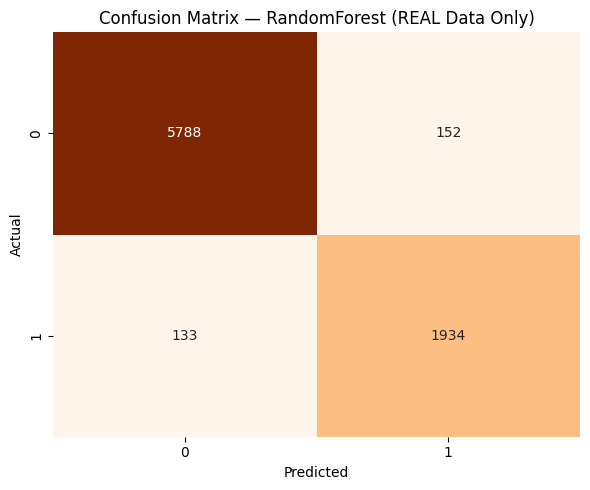

✓ Saved confusion_matrix_real.png


In [22]:
cm_real = confusion_matrix(y_test_real, y_pred_real)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_real, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title(f'Confusion Matrix — {best_model_name} (REAL Data Only)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix_real.png', dpi=150)
plt.show()
print("✓ Saved confusion_matrix_real.png")

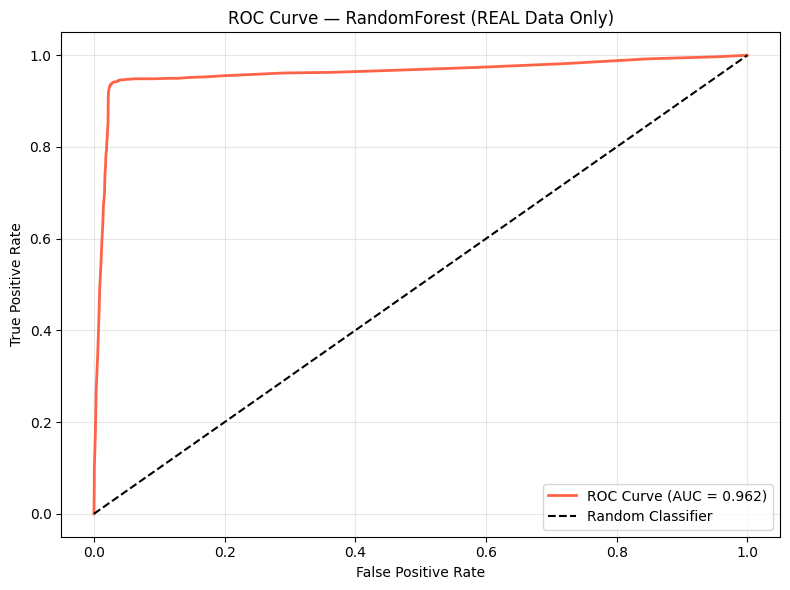

✓ Saved roc_curve_real.png


In [24]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc as sklearn_auc

fpr_real, tpr_real, _ = roc_curve(y_test_real, y_proba_real)
auc_real_curve = sklearn_auc(fpr_real, tpr_real)

plt.figure(figsize=(8, 6))
plt.plot(fpr_real, tpr_real, label=f'ROC Curve (AUC = {auc_real_curve:.3f})', linewidth=2, color='tomato')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve — {best_model_name} (REAL Data Only)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/roc_curve_real.png', dpi=150)
plt.show()
print("✓ Saved roc_curve_real.png")

<Figure size 1000x600 with 0 Axes>

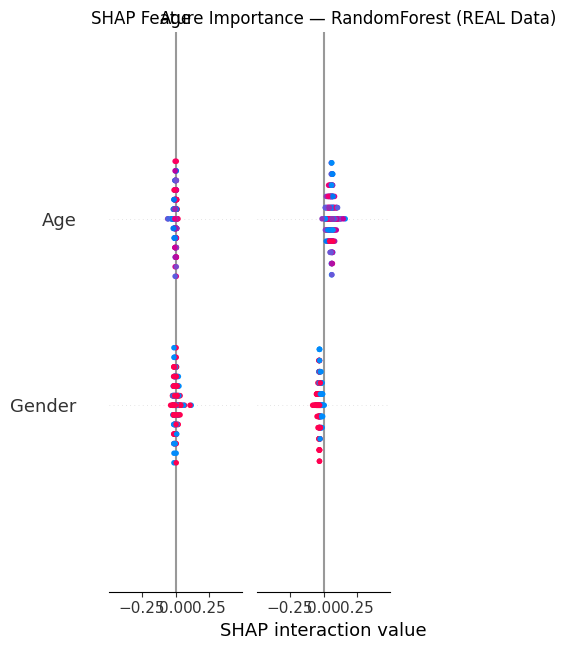

✓ Saved shap_real.png


In [25]:
explainer = shap.TreeExplainer(best_model)

# Use 200 real test samples for SHAP (full dataset is slow)
X_shap = X_test_real.iloc[:200].reset_index(drop=True)
shap_values = explainer.shap_values(X_shap)

# For binary classification pick class 1 (churned)
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_shap, feature_names=X_real.columns.tolist(), show=False)
plt.title(f'SHAP Feature Importance — {best_model_name} (REAL Data)')
plt.tight_layout()
plt.savefig('../reports/shap_real.png', dpi=150)
plt.show()
print("✓ Saved shap_real.png")

In [26]:
print("\n" + "="*55)
print("       FINAL MODEL PERFORMANCE COMPARISON")
print("="*55)
print(f"  Best Model: {best_model_name}")
print("-"*55)
print(f"  Balanced Data (real + synthetic test set):")
print(f"    Accuracy : {best_accuracy:.4f}")
print(f"    ROC-AUC  : {best_auc:.4f}")
print("-"*55)
print(f"  Real Data ONLY (production scenario):")
print(f"    Accuracy : {acc_real:.4f}")
print(f"    ROC-AUC  : {auc_real:.4f}")
print("="*55)
print("\n✓ Reports saved to ../reports/")
print("✓ Model saved to ../models/best_model.pkl")


       FINAL MODEL PERFORMANCE COMPARISON
  Best Model: RandomForest
-------------------------------------------------------
  Balanced Data (real + synthetic test set):
    Accuracy : 0.9672
    ROC-AUC  : 0.9784
-------------------------------------------------------
  Real Data ONLY (production scenario):
    Accuracy : 0.9644
    ROC-AUC  : 0.9616

✓ Reports saved to ../reports/
✓ Model saved to ../models/best_model.pkl


In [6]:
# Pick known samples
active_samples = X[y == 0].sample(5, random_state=42)
churn_samples = X[y == 1].sample(5, random_state=42)

print("=== ACTIVE PLAYERS ===")
print("Pred:", model.predict(active_samples))
print("Prob:", model.predict_proba(active_samples))

print("\n=== CHURNED PLAYERS ===")
print("Pred:", model.predict(churn_samples))
print("Prob:", model.predict_proba(churn_samples))

=== ACTIVE PLAYERS ===
Pred: [1 1 1 1 1]
Prob: [[0.02 0.98]
 [0.03 0.97]
 [0.03 0.97]
 [0.08 0.92]
 [0.   1.  ]]

=== CHURNED PLAYERS ===
Pred: [0 0 0 0 0]
Prob: [[0.98 0.02]
 [0.98 0.02]
 [0.98 0.02]
 [0.96 0.04]
 [1.   0.  ]]
